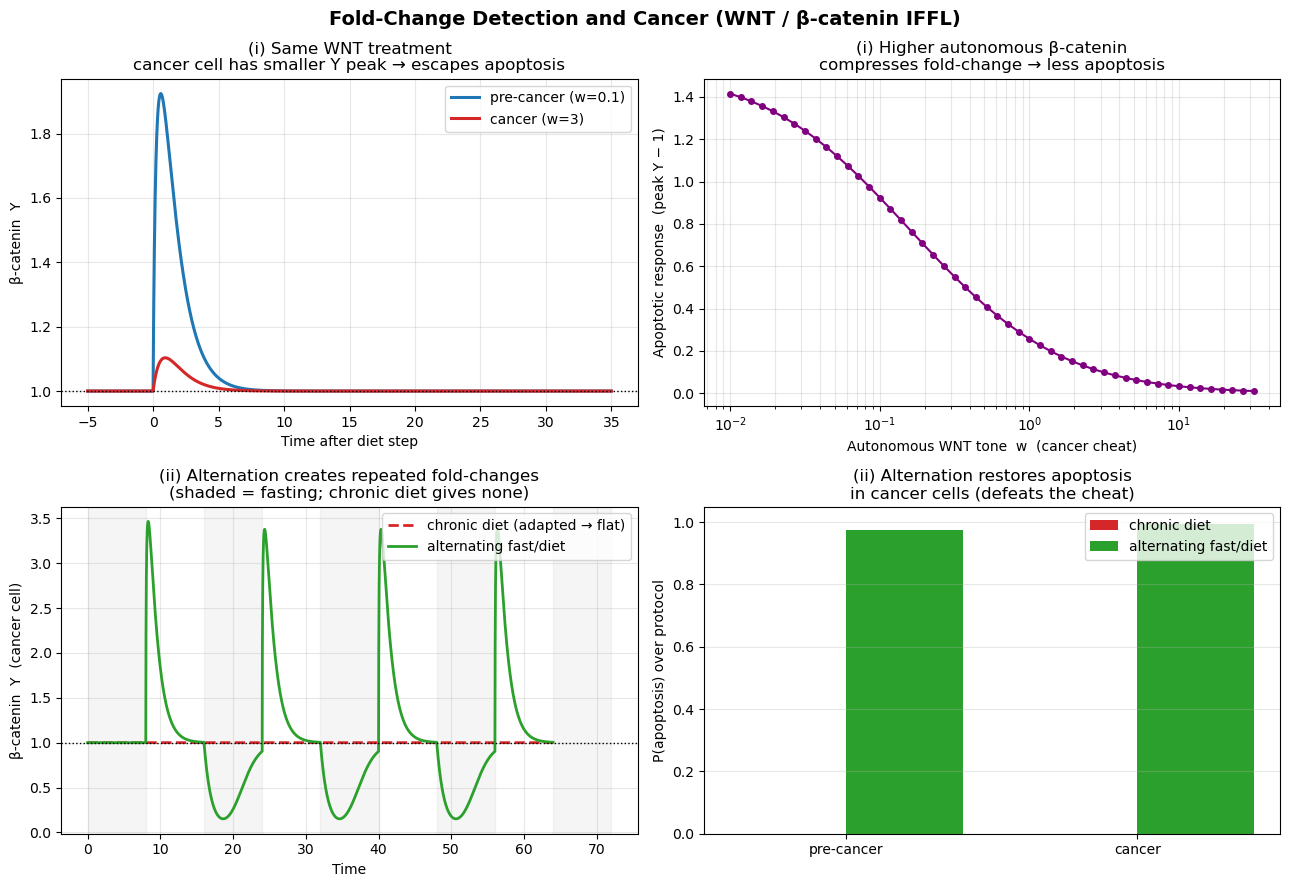

(i) Single WNT (diet) step — same treatment, different cells:
   pre-cancer w=0.1 : peak Y=1.92  apoptotic response=0.92
   cancer     w=3.0 : peak Y=1.10  apoptotic response=0.10
   => cancer cell compresses the fold-change -> escapes apoptosis

(ii) P(apoptosis):
   cell          chronic diet   alternating
   pre-cancer           0.000         0.974
   cancer               0.000         0.994
   => chronic diet: both adapt, no apoptotic signal (~0)
   => alternation: WNT-independent fasting resets baseline,
      restoring large fold-changes -> apoptosis even in cancer


In [3]:
"""
Week 3 – Physics of Molecular Diseases
Fold-Change Detection and Cancer  (IFFL / WNT-beta-catenin)
=====================================================
Base model: incoherent feed-forward loop (FCD detector)
    dx/dt = S - x
    dy/dt = S/x - y
    U = WNT signal,  X = inhibitor,  Y = beta-catenin (output)
    S(t) = u_ext(t) + w*(1 - alpha*fasting(t))

Biology:
    apoptosis of pre-cancer cells  ∝  fold-change of WNT  ∝  FCD transient of Y
    => apoptotic signal = beta-catenin ABOVE its adapted baseline (y - 1)
    => P(apoptosis) = 1 - exp(-k * integral of (y-1)+ dt)

(i)  cancer cells "cheat": autonomous WNT/beta-catenin tone w compresses the
     fold-change of the same WNT treatment -> smaller Y peak -> escape apoptosis
(ii) fasting downregulates beta-catenin WNT-INDEPENDENTLY (suppresses w),
     resetting the baseline; alternating fasting<->Mediterranean-diet then
     delivers repeated large fold-changes -> apoptosis even in cancer cells.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

y0 = 1.0   # adapted baseline of the FCD output

# ============================================================
# SIMULATOR
# ============================================================
def simulate(u_func, fast_func, w, alpha, T, x0, dt=0.01):
    """
    IFFL with total WNT tone S(t) = u_ext(t) + w*(1 - alpha*fasting(t)).
      w     : autonomous (constitutive) WNT/beta-catenin tone  [cancer cheat]
      alpha : strength of fasting's WNT-INDEPENDENT suppression of w
    """
    def S(t):
        return u_func(t) + w*(1.0 - alpha*fast_func(t))
    def rhs(t, s):
        x, y = s
        Sx = S(t)
        return [Sx - x, Sx/max(x, 1e-9) - y]
    sol = solve_ivp(rhs, (0, T), [x0, 1.0],
                    t_eval=np.arange(0, T, dt),
                    rtol=1e-7, atol=1e-9, max_step=0.05)
    return sol.t, sol.y[0], sol.y[1]

def apoptotic_dose(t, y):
    """Cumulative FCD apoptotic signal = integral of beta-catenin ABOVE baseline."""
    return np.trapz(np.clip(y - y0, 0, None), t)   # NumPy 2.0; use np.trapz instead of np.trapezoid on older versions

def P_apoptosis(D, k=0.3):
    """Probability of apoptosis: hazard ∝ Y, so P = 1 - exp(-k * dose)."""
    return 1.0 - np.exp(-k*D)

# ============================================================
# INPUT SCHEDULES
# ============================================================
u_base, u_diet = 0.05, 1.0
period = 8.0

def zero(t):     return 0.0                    # no fasting
def u_step(t):   return u_base if t < 5 else u_diet      # single diet step at t=5
def u_const(t):  return u_diet                 # chronic Mediterranean diet
def u_alt(t):    return u_diet if (int(t//period) % 2 == 1) else u_base   # alternate diet
def fast_alt(t): return 1.0   if (int(t//period) % 2 == 0) else 0.0       # alternate fasting

# ============================================================
# FIGURE
# ============================================================
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

# ---- Panel A: single diet step — pre-cancer vs cancer (the cheat) ----
for lab, w, c in [("pre-cancer (w=0.1)", 0.1, '#1f77b4'),
                  ("cancer (w=3)",       3.0, '#d62728')]:
    t, x, y = simulate(u_step, zero, w=w, alpha=0, T=40, x0=u_base+w)
    ax[0,0].plot(t-5, y, color=c, lw=2.2, label=lab)
ax[0,0].axhline(1, color='k', ls=':', lw=1)
ax[0,0].set_xlabel('Time after diet step'); ax[0,0].set_ylabel('β-catenin  Y')
ax[0,0].set_title('(i) Same WNT treatment\ncancer cell has smaller Y peak → escapes apoptosis')
ax[0,0].legend(); ax[0,0].grid(alpha=0.3)

# ---- Panel B: fold-change compression vs autonomous tone w ----
ws = np.logspace(-2, 1.5, 50)
peaks = []
for w in ws:
    t, x, y = simulate(u_step, zero, w=w, alpha=0, T=40, x0=u_base+w)
    peaks.append(y.max() - 1.0)          # apoptotic FCD response (peak above baseline)
ax[0,1].semilogx(ws, peaks, 'o-', color='purple', ms=4)
ax[0,1].set_xlabel('Autonomous WNT tone  w  (cancer cheat)')
ax[0,1].set_ylabel('Apoptotic response  (peak Y − 1)')
ax[0,1].set_title('(i) Higher autonomous β-catenin\ncompresses fold-change → less apoptosis')
ax[0,1].grid(alpha=0.3, which='both')

# ---- Panel C: cancer cell — chronic diet vs alternating fasting/diet ----
t, x, y = simulate(u_const, zero, w=3.0, alpha=0, T=64, x0=u_diet+3.0)   # adapted to diet
ax[1,0].plot(t, y, color='#d62728', ls='--', lw=2, label='chronic diet (adapted → flat)')
t2, x2, y2 = simulate(u_alt, fast_alt, w=3.0, alpha=1.0, T=64, x0=u_base)
ax[1,0].plot(t2, y2, color='#2ca02c', lw=2, label='alternating fast/diet')
ax[1,0].axhline(1, color='k', ls=':', lw=1)
# shade fasting windows
for kk in range(0, int(64//period)+1, 2):
    ax[1,0].axvspan(kk*period, (kk+1)*period, color='gray', alpha=0.08)
ax[1,0].set_xlabel('Time'); ax[1,0].set_ylabel('β-catenin  Y  (cancer cell)')
ax[1,0].set_title('(ii) Alternation creates repeated fold-changes\n(shaded = fasting; chronic diet gives none)')
ax[1,0].legend(); ax[1,0].grid(alpha=0.3)

# ---- Panel D: apoptosis probability — both cells, both protocols ----
labels = ['pre-cancer', 'cancer']
chronic, altern = [], []
for w in [0.1, 3.0]:
    t, x, y = simulate(u_const, zero, w=w, alpha=0, T=64, x0=u_diet+w)
    chronic.append(P_apoptosis(apoptotic_dose(t, y)))
    t2, x2, y2 = simulate(u_alt, fast_alt, w=w, alpha=1.0, T=64, x0=u_base)
    altern.append(P_apoptosis(apoptotic_dose(t2, y2)))
xp = np.arange(2)
ax[1,1].bar(xp-0.2, chronic, 0.4, color='#d62728', label='chronic diet')
ax[1,1].bar(xp+0.2, altern,  0.4, color='#2ca02c', label='alternating fast/diet')
ax[1,1].set_xticks(xp); ax[1,1].set_xticklabels(labels)
ax[1,1].set_ylabel('P(apoptosis) over protocol'); ax[1,1].set_ylim(0, 1.05)
ax[1,1].set_title('(ii) Alternation restores apoptosis\nin cancer cells (defeats the cheat)')
ax[1,1].legend(); ax[1,1].grid(alpha=0.3, axis='y')

plt.suptitle('Fold-Change Detection and Cancer (WNT / β-catenin IFFL)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# CONSOLE SUMMARY
# ============================================================
print("="*60)
print("(i) Single WNT (diet) step — same treatment, different cells:")
for lab, w in [("pre-cancer", 0.1), ("cancer", 3.0)]:
    t, x, y = simulate(u_step, zero, w=w, alpha=0, T=40, x0=u_base+w)
    print(f"   {lab:10s} w={w:<4}: peak Y={y.max():.2f}  apoptotic response={y.max()-1:.2f}")
print("   => cancer cell compresses the fold-change -> escapes apoptosis")
print("\n(ii) P(apoptosis):")
print(f"   {'cell':12s}{'chronic diet':>14}{'alternating':>14}")
for lab, c, a in zip(labels, chronic, altern):
    print(f"   {lab:12s}{c:>14.3f}{a:>14.3f}")
print("   => chronic diet: both adapt, no apoptotic signal (~0)")
print("   => alternation: WNT-independent fasting resets baseline,")
print("      restoring large fold-changes -> apoptosis even in cancer")
print("="*60)